In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [9]:
sns.set_theme(style="whitegrid")

In [10]:
df = pd.read_csv('C:\\Users\\uma kushwah\\OneDrive\\Documents\\Project_A\\cardio_train (1).csv')

In [11]:
print(df.shape, "\n")

(70000, 1) 



In [12]:
df = pd.read_csv('C:\\Users\\uma kushwah\\OneDrive\\Documents\\Project_A\\cardio_train (1).csv', sep=';')

In [13]:
df['age'] = (df['age'] / 365.25).round().astype(int)

In [14]:
df = df[(df['ap_hi'] >= 80) & (df['ap_hi'] <= 250)]
df = df[(df['ap_lo'] >= 50) & (df['ap_lo'] <= 150)]

In [15]:
df = df[df['ap_hi'] > df['ap_lo']]

In [16]:
print(df.shape, "\n")

(68645, 13) 



EDA

C:\Users\uma kushwah\AppData\Local\Temp\ipykernel_5480\4245706189.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='cardio', palette='Set2')


Text(0.5, 1.0, 'Distribution of Cardiovascular Disease (Target)')

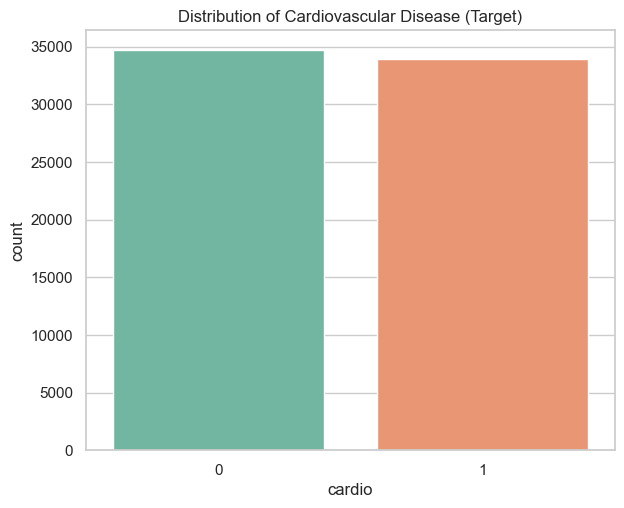

In [17]:
plt.figure(figsize=(15, 12))
plt.subplot(2, 2, 1)
sns.countplot(data=df, x='cardio', palette='Set2')
plt.title('Distribution of Cardiovascular Disease (Target)')

Text(0.5, 1.0, 'Age Distribution Segmented by Heart Disease')

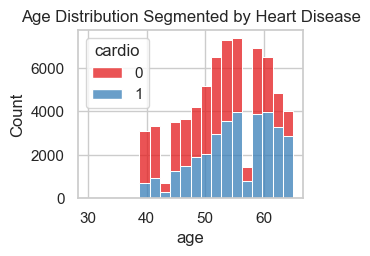

In [18]:
plt.subplot(2, 2, 2)
sns.histplot(data=df, x='age', hue='cardio', multiple='stack', bins=20, palette='Set1')
plt.title('Age Distribution Segmented by Heart Disease')

Text(0.5, 1.0, 'Cholesterol Levels (1=Normal, 2=Above, 3=Well Above)')

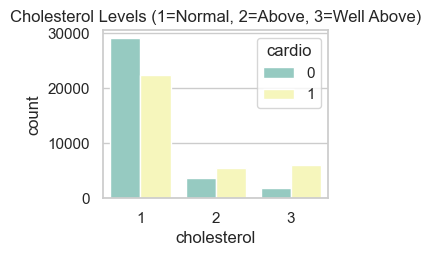

In [19]:
plt.subplot(2, 2, 3)
sns.countplot(data=df, x='cholesterol', hue='cardio', palette='Set3')
plt.title('Cholesterol Levels (1=Normal, 2=Above, 3=Well Above)')

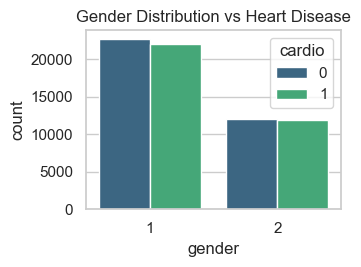

In [20]:
plt.subplot(2, 2, 4)
sns.countplot(data=df, x='gender', hue='cardio', palette='viridis')
plt.title('Gender Distribution vs Heart Disease')

plt.tight_layout()
plt.show()

Correlation Matrix

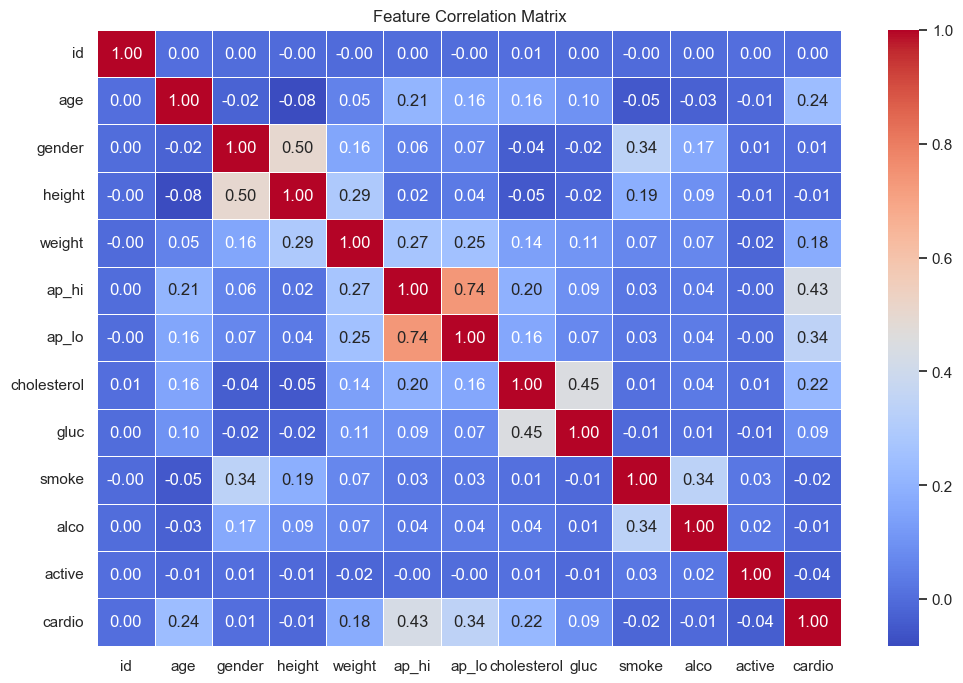

In [21]:
plt.figure(figsize=(12, 8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

ML Model Training

In [22]:
X = df.drop('cardio', axis=1)
y = df['cardio']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
models = {
    "Logistic Regression (LR)": LogisticRegression(),
    "K-Nearest Neighbor (KNN)": KNeighborsClassifier(n_neighbors=5),
    "Decision Trees (DT)": DecisionTreeClassifier(random_state=42),
    "Random Forest (RF)": RandomForestClassifier(n_estimators=100, random_state=42),
    "Support Vector Machines (SVM)": SVC(kernel='rbf') 
}

# Dictionary to store accuracies
accuracy_results = {}

print("--- Model Accuracy Results ---")
for name, model in models.items():
    # Train the model
    model.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test_scaled)
    
    # Calculate accuracy
    acc = accuracy_score(y_test, y_pred)
    accuracy_results[name] = acc
    print(f"{name}: {acc * 100:.2f}%")

--- Model Accuracy Results ---
Logistic Regression (LR): 72.46%
K-Nearest Neighbor (KNN): 68.98%
Decision Trees (DT): 63.44%
Random Forest (RF): 71.50%
Support Vector Machines (SVM): 73.04%


In [24]:
best_model_name = max(accuracy_results, key=accuracy_results.get)
best_model_acc = accuracy_results[best_model_name]

print("\n--- Final Conclusion ---")
print(f"The best performing model is {best_model_name} with an accuracy of {best_model_acc * 100:.2f}%.")


--- Final Conclusion ---
The best performing model is Support Vector Machines (SVM) with an accuracy of 73.04%.


C:\Users\uma kushwah\AppData\Local\Temp\ipykernel_5480\2591906428.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(accuracy_results.values()), y=list(accuracy_results.keys()), palette='magma')


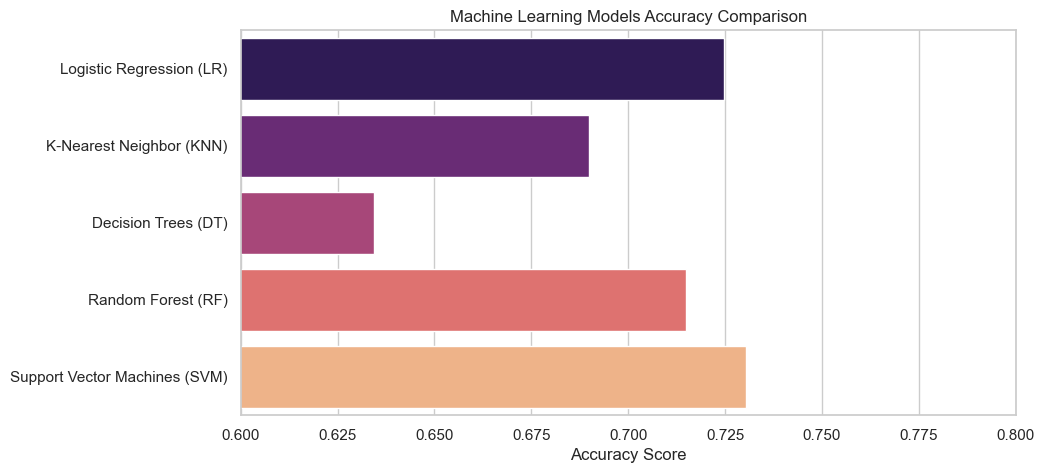

In [25]:
plt.figure(figsize=(10, 5))
sns.barplot(x=list(accuracy_results.values()), y=list(accuracy_results.keys()), palette='magma')
plt.title('Machine Learning Models Accuracy Comparison')
plt.xlabel('Accuracy Score')
plt.xlim(0.6, 0.8) # Adjusted for better visual differentiation
plt.show()